# IS 455 — Fraud Detection ML Pipeline
**CRISP-DM Process | Chapters 1–17**

## 1. Business Understanding (Ch. 1)
**Problem:** Predict whether an order is fraudulent (`is_fraud`) using order, customer, and shipment data.  
**Success criteria:** Maximize recall (catch real fraud) while keeping precision reasonable. Target F1 ≥ 0.75 on test set.

## 2. Data Understanding (Ch. 6, 8)

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectFromModel
import joblib
import warnings
warnings.filterwarnings('ignore')

import os
DB_PATH = os.path.join(os.getcwd(), 'ShopProject', 'backend', 'ShopProject.API', 'shop.db')


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load data from SQLite (Ch. 6)
conn = sqlite3.connect(DB_PATH)

query = """
SELECT
    o.order_id,
    o.order_datetime,
    o.payment_method,
    o.device_type,
    o.ip_country,
    o.promo_used,
    o.order_subtotal,
    o.shipping_fee,
    o.tax_amount,
    o.order_total,
    o.risk_score,
    o.billing_zip,
    o.shipping_zip,
    o.shipping_state,
    o.is_fraud,
    c.gender,
    c.customer_segment,
    c.loyalty_tier,
    c.is_active AS customer_active,
    c.state AS customer_state,
    s.carrier,
    s.shipping_method,
    s.distance_band,
    s.late_delivery,
    COUNT(oi.order_item_id) AS item_count,
    SUM(oi.quantity) AS total_qty
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN shipments s ON o.order_id = s.order_id
LEFT JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY o.order_id
"""

df = pd.read_sql(query, conn)
conn.close()
print(df.shape)
df.head()

(5000, 26)


,order_id,order_datetime,payment_method,device_type,ip_country,promo_used,order_subtotal,shipping_fee,tax_amount,order_total,...,customer_segment,loyalty_tier,customer_active,customer_state,carrier,shipping_method,distance_band,late_delivery,item_count,total_qty
0,1,2025-11-29 00:51:07,card,mobile,US,0,662.95,15.44,46.30,724.69,...,standard,silver,1,CO,UPS,expedited,regional,1,5,9
1,2,2025-09-01 10:25:59,card,desktop,US,1,862.92,14.74,66.61,944.27,...,standard,silver,1,CO,FedEx,expedited,local,1,5,7
2,3,2025-12-15 07:24:41,card,mobile,US,0,796.09,14.04,40.72,850.85,...,standard,silver,1,CO,FedEx,expedited,national,1,3,5
3,4,2025-11-06 18:21:19,bank,mobile,US,1,137.60,6.99,11.88,156.47,...,standard,silver,1,CO,UPS,standard,regional,0,1,1
4,5,2025-11-30 05:34:15,card,mobile,CA,0,17.07,6.99,1.40,25.46,...,standard,silver,1,CO,USPS,standard,regional,1,1,1


In [3]:
# Class balance
print(df['is_fraud'].value_counts())
print(f"Fraud rate: {df['is_fraud'].mean():.2%}")

is_fraud
0    4682
1     318
Name: count, dtype: int64
Fraud rate: 6.36%


In [4]:
# Missing values
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

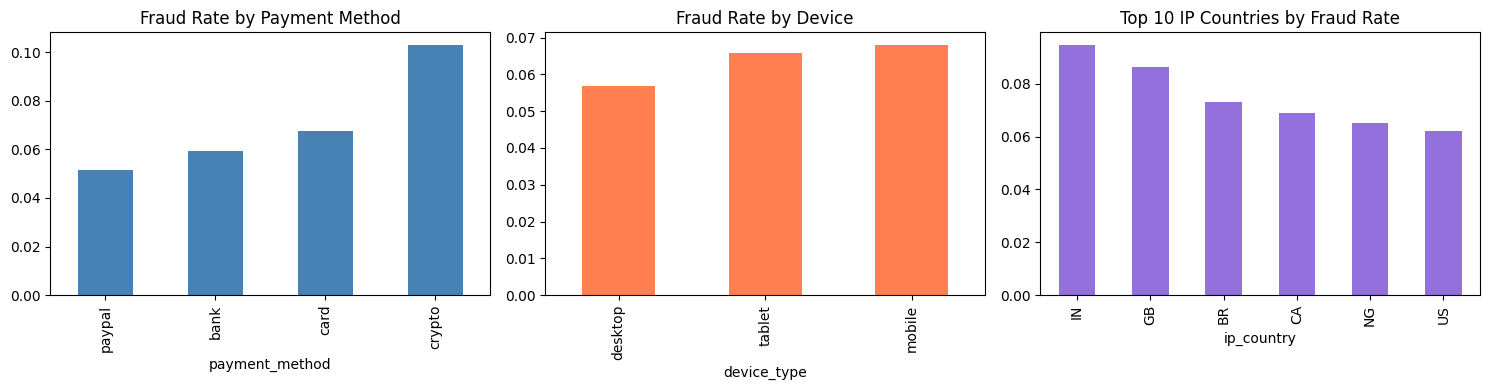

In [5]:
# Relationship exploration (Ch. 8)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('payment_method')['is_fraud'].mean().sort_values().plot(kind='bar', ax=axes[0], title='Fraud Rate by Payment Method', color='steelblue')
df.groupby('device_type')['is_fraud'].mean().sort_values().plot(kind='bar', ax=axes[1], title='Fraud Rate by Device', color='coral')
df.groupby('ip_country')['is_fraud'].mean().sort_values(ascending=False).head(10).plot(kind='bar', ax=axes[2], title='Top 10 IP Countries by Fraud Rate', color='mediumpurple')

plt.tight_layout()
plt.show()

In [6]:
# Numeric distributions
num_cols = ['order_total', 'risk_score', 'item_count', 'total_qty']
df[num_cols + ['is_fraud']].groupby('is_fraud').mean().T

is_fraud,0,1
order_total,405.151950,663.003050
risk_score,24.185092,54.544340
item_count,2.958778,3.676101
total_qty,4.027552,5.308176


## 3. Data Preparation (Ch. 2–4, 7)

In [7]:
# Feature engineering (Ch. 2–4)
df['order_hour'] = pd.to_datetime(df['order_datetime']).dt.hour
df['order_dow']  = pd.to_datetime(df['order_datetime']).dt.dayofweek
df['zip_mismatch'] = (df['billing_zip'] != df['shipping_zip']).astype(int)
df['state_mismatch'] = (df['customer_state'] != df['shipping_state']).astype(int)
df['foreign_ip'] = (df['ip_country'] != 'US').astype(int)
df['high_value'] = (df['order_total'] > df['order_total'].quantile(0.90)).astype(int)

TARGET = 'is_fraud'
DROP_COLS = ['order_id', 'order_datetime', 'billing_zip', 'shipping_zip',
             'shipping_state', 'customer_state', 'ip_country', TARGET]

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

# Define feature types
num_feats = X.select_dtypes(include='number').columns.tolist()
cat_feats = X.select_dtypes(include='object').columns.tolist()

print('Numeric:', num_feats)
print('Categorical:', cat_feats)

Numeric: ['promo_used', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'customer_active', 'late_delivery', 'item_count', 'total_qty', 'order_hour', 'order_dow', 'zip_mismatch', 'state_mismatch', 'foreign_ip', 'high_value']
Categorical: ['payment_method', 'device_type', 'gender', 'customer_segment', 'loyalty_tier', 'carrier', 'shipping_method', 'distance_band']


In [8]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (4000, 24)  Test: (1000, 24)


In [9]:
# Automated preparation pipeline (Ch. 7)
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])

cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_feats),
    ('cat', cat_pipe, cat_feats)
])

## 4. Modeling (Ch. 13, 14)

In [10]:
# Compare three classifiers (Ch. 13 + Ch. 14 ensemble methods)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    results[name] = scores
    print(f"{name}: CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: CV F1 = 0.3082 ± 0.0229
Random Forest: CV F1 = 0.0000 ± 0.0000
Gradient Boosting: CV F1 = 0.0656 ± 0.0675


## 5. Evaluation, Selection & Tuning (Ch. 15, 16)

In [11]:
# Hyperparameter tuning on best model — Random Forest (Ch. 15)
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth':    [None, 10, 20],
    'clf__min_samples_leaf': [1, 5]
}

best_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

gs = GridSearchCV(best_pipe, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_)
print('Best CV F1:', round(gs.best_score_, 4))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
Best CV F1: 0.2677


In [12]:
# Evaluate on hold-out test set
final_model = gs.best_estimator_
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

       Legit       0.96      0.92      0.94       936
       Fraud       0.27      0.42      0.33        64

    accuracy                           0.89      1000
   macro avg       0.61      0.67      0.63      1000
weighted avg       0.91      0.89      0.90      1000

ROC-AUC: 0.8371


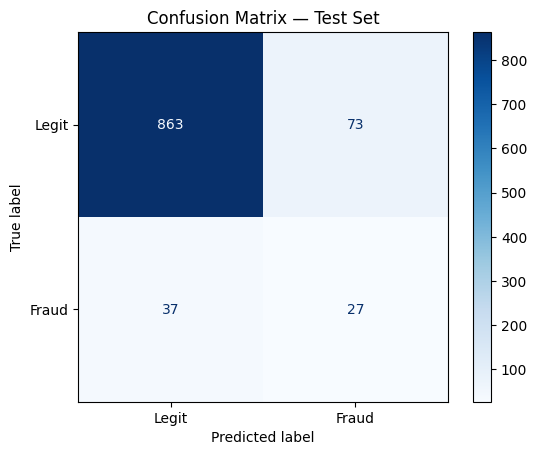

In [13]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legit', 'Fraud'], cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.show()

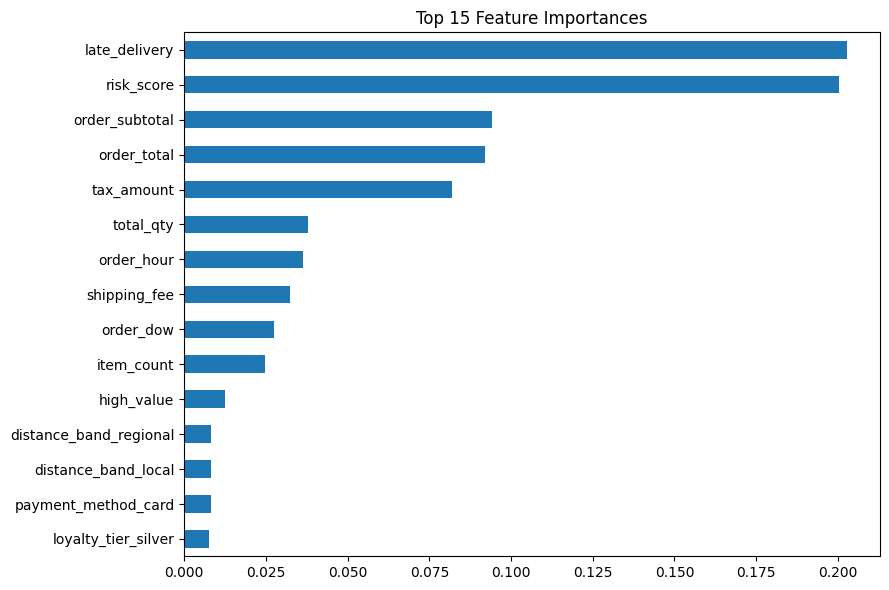

In [14]:
# Feature importance + selection (Ch. 16)
rf = final_model.named_steps['clf']
ohe_cols = final_model.named_steps['prep'].transformers_[1][1].named_steps['encode'].get_feature_names_out(cat_feats)
feature_names = num_feats + list(ohe_cols)

importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

importances.head(15).plot(kind='barh', figsize=(9, 6), title='Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Deployment — Serialize & Demonstrate (Ch. 17)

In [15]:
# Serialize the full pipeline (Ch. 17)
MODEL_PATH = os.path.join(os.getcwd(), 'fraud_model.pkl')
joblib.dump(final_model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to fraud_model.pkl


In [16]:
# Demonstrate loading and running in a production-style function (Ch. 17)
def predict_fraud(order_record: dict) -> dict:
    """Load serialized model and score a single order record."""
    model = joblib.load(MODEL_PATH)
    record_df = pd.DataFrame([order_record])
    prob = model.predict_proba(record_df)[0, 1]
    label = int(model.predict(record_df)[0])
    return {'is_fraud': label, 'fraud_probability': round(prob, 4)}

# Test with a sample row from the test set
sample = X_test.iloc[0].to_dict()
result = predict_fraud(sample)
print('Prediction:', result)
print('Actual label:', y_test.iloc[0])

Prediction: {'is_fraud': 0, 'fraud_probability': np.float64(0.0056)}
Actual label: 0
